<a href="https://colab.research.google.com/github/DewyV3582/Stock-Price-Dashboard-/blob/main/Stock_price_Dashboard2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stock Price Dashboard 2
A Python tool that pulls live stock data, charts closing price with a 20-day moving average,
and adds RSI (Relative Strength Index) to flag overbought/oversold conditions.

Built with: yfinance, pandas, matplotlib

## Usage
plot_ticker("TICKER") — pass any stock symbol to generate its chart

In [27]:
ticker = "RIVN"
data = yf.download(ticker, period="6mo", interval="1d")
data.head()

/tmp/ipykernel_439/2554248819.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="6mo", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RIVN,RIVN,RIVN,RIVN,RIVN
Date,,,,,
2026-02-19,15.59,15.960,15.070,15.930,28703600
2026-02-20,15.27,15.420,15.010,15.335,20860500
2026-02-23,14.96,15.355,14.695,15.085,17459800
2026-02-24,15.12,15.350,14.735,15.095,21025300
2026-02-25,15.25,15.705,15.180,15.300,19283200


In [28]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
ticker = "RIVN"
data = yf.download(ticker, period="6mo", interval="1d")
data.head()

/tmp/ipykernel_439/2554248819.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="6mo", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RIVN,RIVN,RIVN,RIVN,RIVN
Date,,,,,
2026-02-19,15.59,15.960,15.070,15.930,28703600
2026-02-20,15.27,15.420,15.010,15.335,20860500
2026-02-23,14.96,15.355,14.695,15.085,17459800
2026-02-24,15.12,15.350,14.735,15.095,21025300
2026-02-25,15.25,15.705,15.180,15.300,19283200


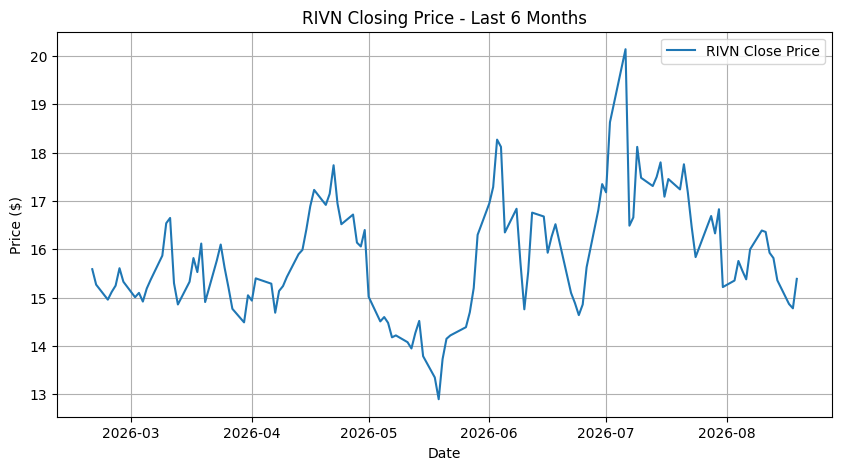

In [30]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='RIVN Close Price')
plt.title(f'{ticker} Closing Price - Last 6 Months')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

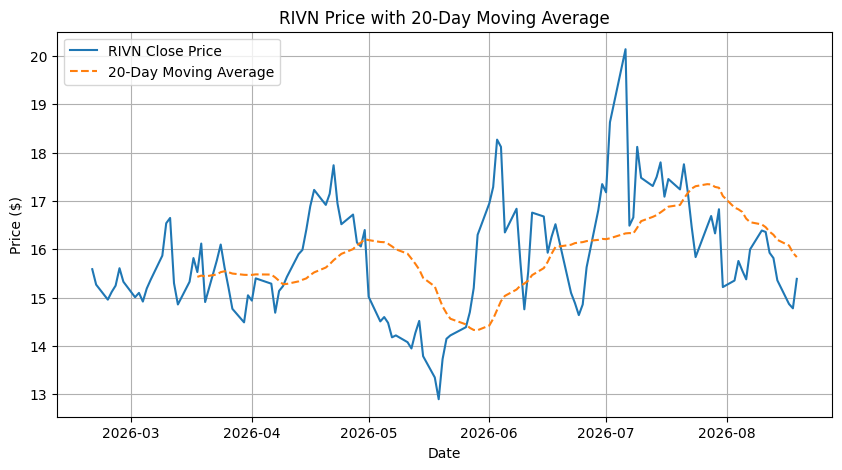

In [31]:
data['MA20'] = data['Close'].rolling(window=20).mean()

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='RIVN Close Price')
plt.plot(data['MA20'], label='20-Day Moving Average', linestyle='--')
plt.title(f'{ticker} Price with 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
def plot_ticker(ticker, period="6mo"):
    data = yf.download(ticker, period=period, interval="1d")
    data['MA20'] = data['Close'].rolling(window=20).mean()
    data['RSI'] = calculate_rsi(data)

    plt.figure(figsize=(10,5))
    plt.plot(data['Close'], label=f'{ticker} Close Price')
    plt.plot(data['MA20'], label='20-Day Moving Average', linestyle='--')
    plt.title(f'{ticker} Price with 20-Day Moving Average')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(data[['Close', 'RSI']].tail(5))

    return data

/tmp/ipykernel_439/1829645436.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed


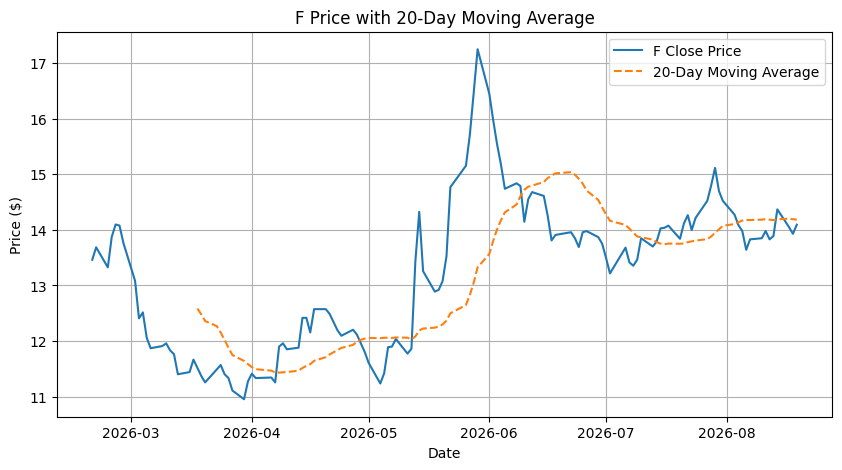

/tmp/ipykernel_439/1829645436.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed

Price         Close        RSI
Ticker            F           
Date                          
2026-08-13  13.8900  44.421087
2026-08-14  14.3700  47.533163
2026-08-17  14.0500  38.055624
2026-08-18  13.9300  29.837319
2026-08-19  14.0938  38.718082


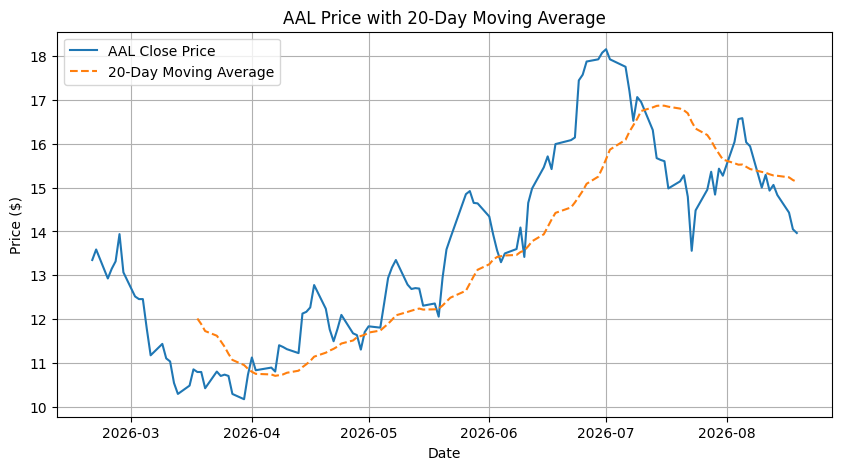

/tmp/ipykernel_439/1829645436.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed

Price        Close        RSI
Ticker         AAL           
Date                         
2026-08-13  15.060  54.982826
2026-08-14  14.830  48.924732
2026-08-17  14.430  41.651710
2026-08-18  14.050  42.725598
2026-08-19  13.965  35.126900


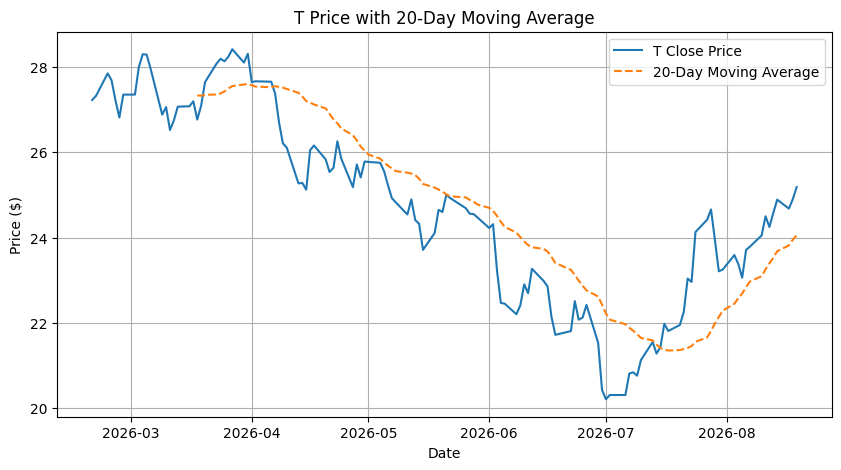

Price           Close        RSI
Ticker              T           
Date                            
2026-08-13  24.580000  54.582489
2026-08-14  24.889999  54.766725
2026-08-17  24.680000  50.204086
2026-08-18  24.900000  60.909077
2026-08-19  25.184999  74.968400


Price,Close,High,Low,Open,Volume,MA20,RSI
Ticker,T,T,T,T,T,,
Date,,,,,,,
2026-02-19,27.226665,27.734480,27.080181,27.363386,31221900,NaN,NaN
2026-02-20,27.324324,27.402449,26.894636,27.295028,25383600,NaN,NaN
2026-02-23,27.851671,28.154406,27.373154,27.382920,41169300,NaN,NaN
2026-02-24,27.685654,28.125107,27.529403,27.851670,34541700,NaN,NaN
2026-02-25,27.216904,27.627062,27.050887,27.373154,45550700,NaN,NaN
...,...,...,...,...,...,...,...
2026-08-13,24.580000,24.680000,24.219999,24.280001,35277700,23.52700,54.582489
2026-08-14,24.889999,24.969999,24.580000,24.650000,27109300,23.68100,54.766725


In [33]:
plot_ticker("F")
plot_ticker("AAL")
plot_ticker("T")

In [34]:
def plot_ticker(ticker, period="6mo"):
    data = yf.download(ticker, period=period, interval="1d")
    data['MA20'] = data['Close'].rolling(window=20).mean()
    data['RSI'] = calculate_rsi(data)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # Top chart: price + moving average
    ax1.plot(data['Close'], label=f'{ticker} Close Price')
    ax1.plot(data['MA20'], label='20-Day Moving Average', linestyle='--')
    ax1.set_title(f'{ticker} Price with 20-Day Moving Average')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True)

    # Bottom chart: RSI
    ax2.plot(data['RSI'], color='purple', label='RSI (14)')
    ax2.axhline(70, color='red', linestyle='--', linewidth=1)
    ax2.axhline(30, color='green', linestyle='--', linewidth=1)
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return data

/tmp/ipykernel_439/2741418040.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed


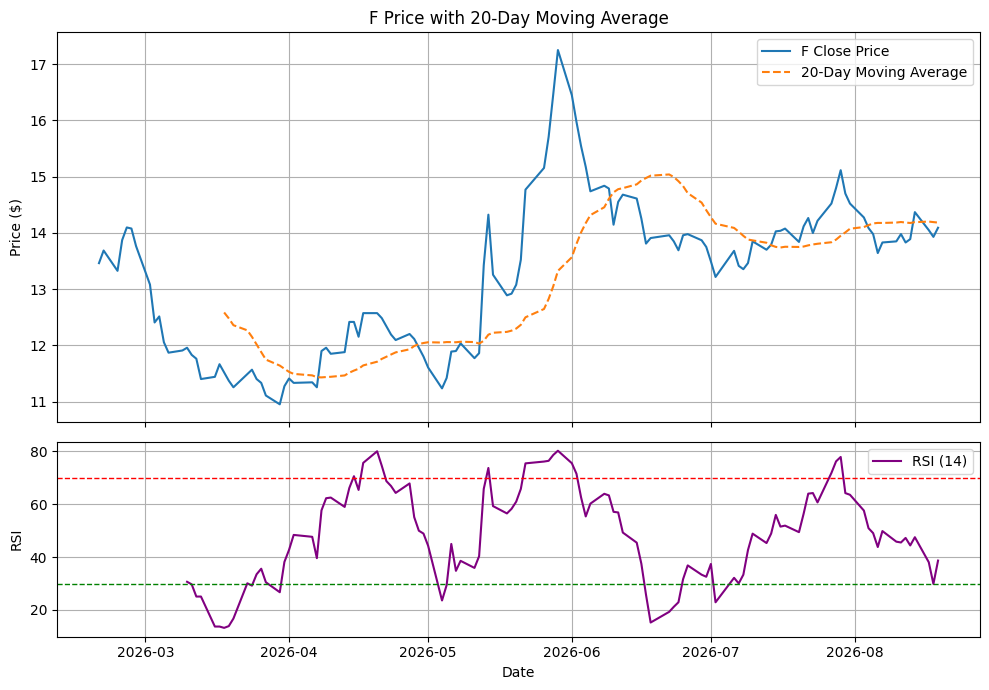

/tmp/ipykernel_439/2741418040.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed


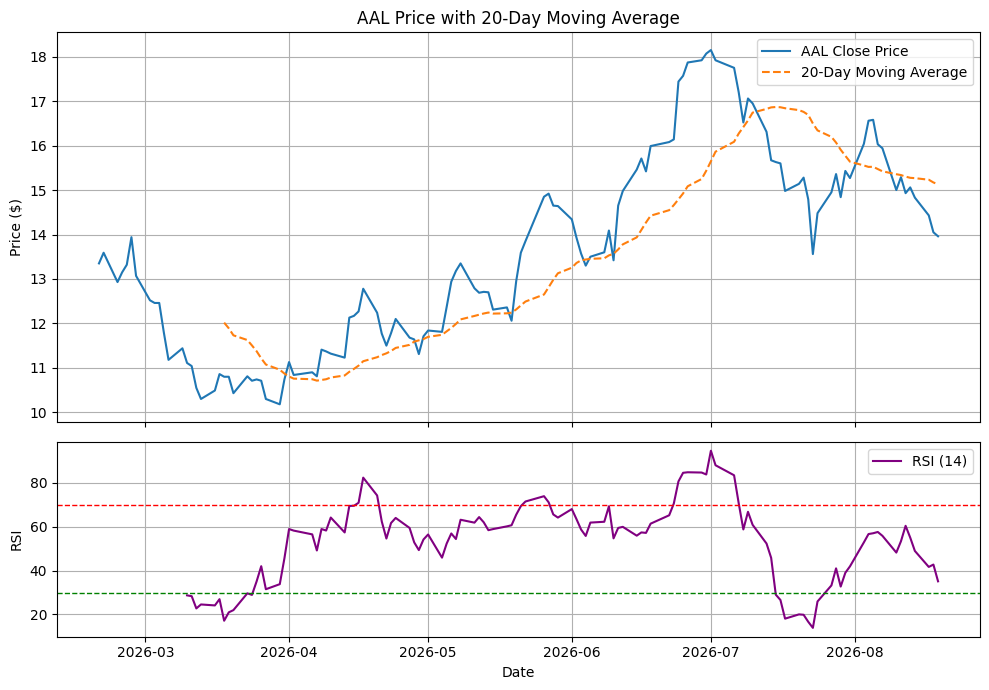

/tmp/ipykernel_439/2741418040.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval="1d")
[*********************100%***********************]  1 of 1 completed


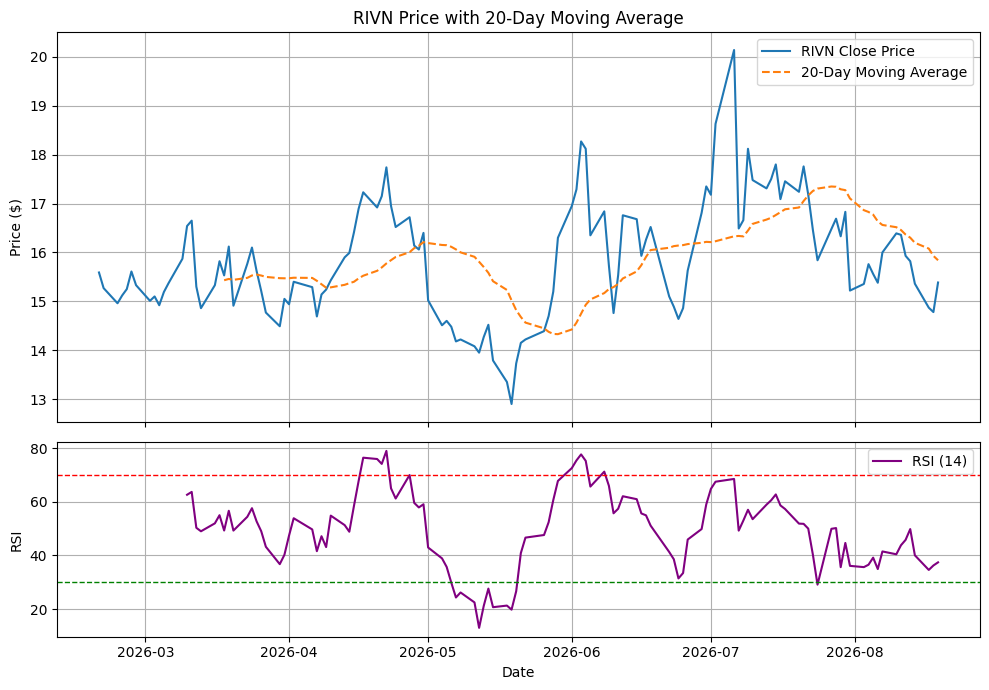

In [35]:
plot_ticker("F");
plot_ticker("AAL");
plot_ticker("RIVN");